# Envelope loss visualization

This notebook visualizes the **envelope-based ESR loss** used in the project.

We will:
- Create simple target and predicted audio signals
- Compute the signal envelopes
- Compute the envelope ESR loss
- Plot both the raw waveforms and their envelopes for intuition


In [1]:
import torch
import matplotlib.pyplot as plt

from models import _envelope_analytic, envelope_loss


Envelope ESR loss: 0.098881


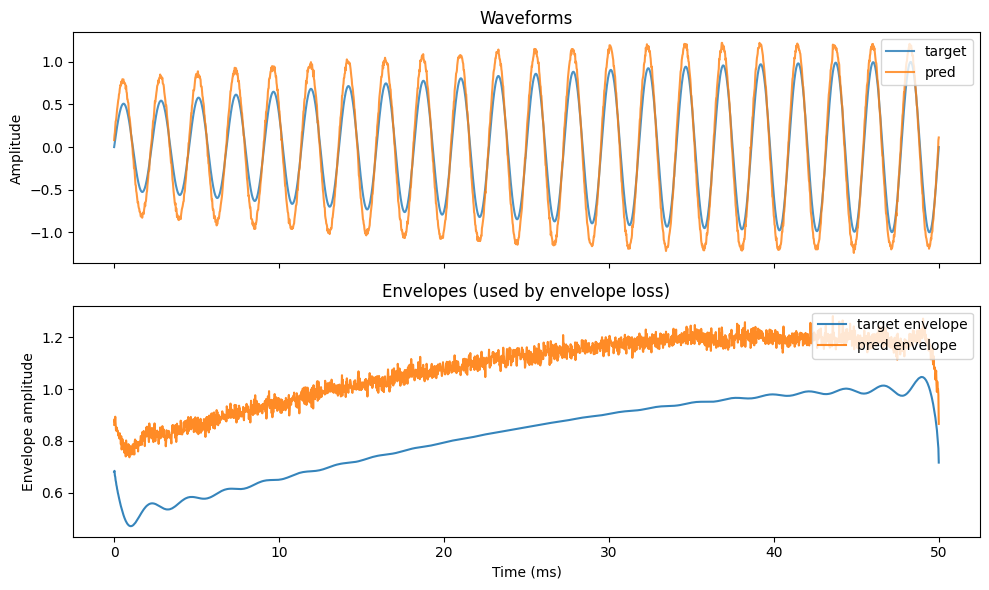

In [2]:
# Generate example signals
sample_rate = 44100
duration = 0.05  # seconds
t = torch.linspace(0, duration, int(sample_rate * duration), dtype=torch.float32)

# Target: clean sine with slow amplitude modulation
carrier_freq = 440.0
mod_freq = 5.0
mod = 0.5 * (1.0 + torch.sin(2 * torch.pi * mod_freq * t))
target = mod * torch.sin(2 * torch.pi * carrier_freq * t)

# Prediction: slightly wrong modulation depth and phase + small noise
mod_pred = 0.6 * (1.0 + torch.sin(2 * torch.pi * mod_freq * t + 0.3))
pred = mod_pred * torch.sin(2 * torch.pi * carrier_freq * t + 0.1)
pred = pred + 0.02 * torch.randn_like(pred)

# Compute envelopes and envelope ESR loss
with torch.no_grad():
    env_target = _envelope_analytic(target)
    env_pred = _envelope_analytic(pred)
    loss_val = envelope_loss(pred, target).item()

print(f"Envelope ESR loss: {loss_val:.6f}")

# Plot waveforms and envelopes
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Raw waveforms (zoomed to the same short window)
axes[0].plot(t * 1000.0, target, label="target", alpha=0.8)
axes[0].plot(t * 1000.0, pred, label="pred", alpha=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveforms")
axes[0].legend(loc="upper right")

# Envelopes
axes[1].plot(t * 1000.0, env_target, label="target envelope", alpha=0.9)
axes[1].plot(t * 1000.0, env_pred, label="pred envelope", alpha=0.9)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Envelope amplitude")
axes[1].set_title("Envelopes (used by envelope loss)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [3]:
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets

from models import _envelope_analytic, envelope_loss


# Interactive visualization of envelope ESR loss
sample_rate = 44100
duration = 0.05  # seconds


def make_target_and_time():
    t = torch.linspace(0, duration, int(sample_rate * duration), dtype=torch.float32)
    carrier_freq = 440.0
    mod_freq = 5.0
    mod = 0.5 * (1.0 + torch.sin(2 * torch.pi * mod_freq * t))
    target = mod * torch.sin(2 * torch.pi * carrier_freq * t)
    return t, target


def plot_interactive(mod_depth=0.6, phase=0.3, noise=0.02):
    t, target = make_target_and_time()
    carrier_freq = 440.0
    mod_freq = 5.0

    # Predicted signal based on slider parameters
    mod_pred = mod_depth * (1.0 + torch.sin(2 * torch.pi * mod_freq * t + phase))
    pred = mod_pred * torch.sin(2 * torch.pi * carrier_freq * t + 0.1)
    if noise > 0.0:
        pred = pred + noise * torch.randn_like(pred)

    with torch.no_grad():
        env_target = _envelope_analytic(target)
        env_pred = _envelope_analytic(pred)
        loss_val = envelope_loss(pred, target).item()

    # Common y-limits across both plots (waveforms + envelopes)
    max_abs = float(
        torch.stack([
            target.abs().max(),
            pred.abs().max(),
            env_target.abs().max(),
            env_pred.abs().max(),
        ]).max()
    )
    max_abs = max(max_abs, 1e-3)
    ylim = (-1.1 * max_abs, 1.1 * max_abs)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Raw waveforms
    axes[0].plot(t * 1000.0, target, label="target", alpha=0.8)
    axes[0].plot(t * 1000.0, pred, label="pred", alpha=0.8)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Waveforms (Envelope ESR loss = {loss_val:.6f})")
    axes[0].legend(loc="upper right")
    axes[0].set_ylim(*ylim)

    # Envelopes
    axes[1].plot(t * 1000.0, env_target, label="target envelope", alpha=0.9)
    axes[1].plot(t * 1000.0, env_pred, label="pred envelope", alpha=0.9)
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("Envelope amplitude")
    axes[1].set_title("Envelopes (used by envelope ESR loss)")
    axes[1].legend(loc="upper right")
    axes[1].set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_interactive,
    mod_depth=widgets.FloatSlider(min=0.2, max=1.2, step=0.05, value=0.6, description="Mod depth"),
    phase=widgets.FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.3, description="Phase offset"),
    noise=widgets.FloatSlider(min=0.0, max=0.1, step=0.005, value=0.02, description="Noise std"),
);

interactive(children=(FloatSlider(value=0.6, description='Mod depth', max=1.2, min=0.2, step=0.05), FloatSlide…

INFO:dataloader:Found 66 paired input/target files in Train subset under /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Train
INFO:dataloader:Found 15 paired input/target files in Val subset under /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Val
INFO:dataloader:Found 3 paired input/target files in Test subset under /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Test
INFO:dataloader:Created dataloaders: train=66, val=15
INFO:dataloader:Test dataset size: 3


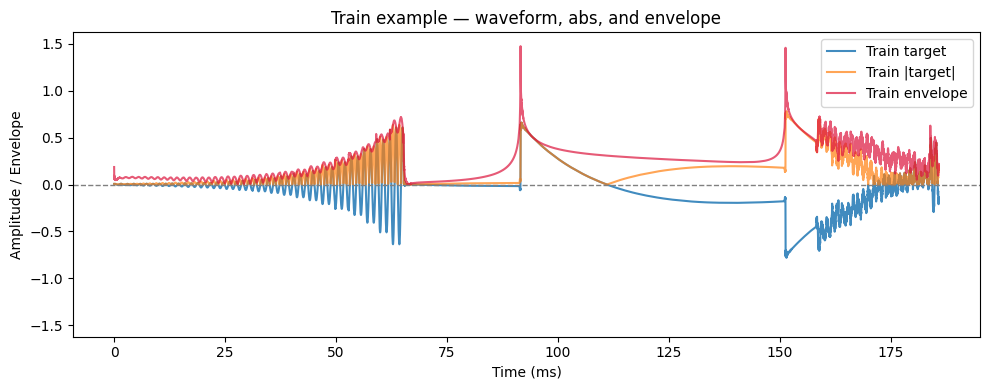

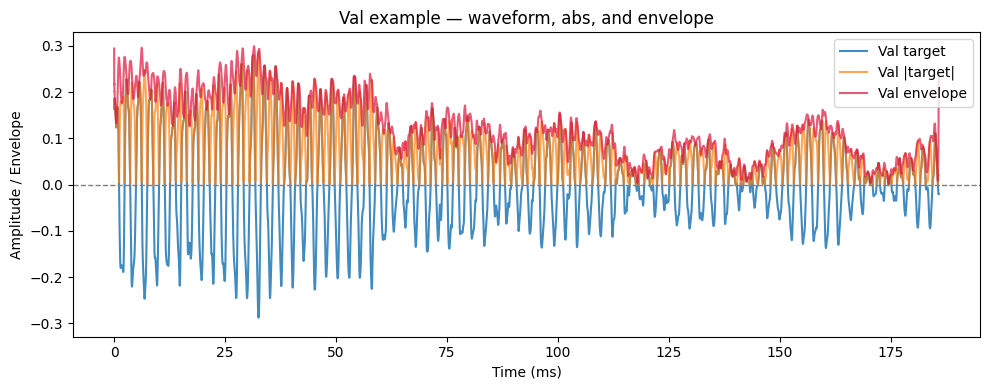

In [4]:
import torch
import matplotlib.pyplot as plt

from dataloader import DatasetConfig, create_dataloaders
from models import _envelope_analytic

# Visualize envelopes from train/val dataloaders
# NOTE: adjust ROOT_DIR below to point to your SignalTrain LA2A dataset root if needed.
ROOT_DIR = "/home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1"
SAMPLE_RATE = 44100
SEGMENT_LENGTH = 8192
BATCH_SIZE = 4

config = DatasetConfig(
    root_dir=ROOT_DIR,
    train_subset="Train",
    val_subset="Val",
    test_subset="Test",
    train_length=SEGMENT_LENGTH,
    eval_length=SEGMENT_LENGTH,
    sample_rate=SAMPLE_RATE,
    n_params=2,
    preload=False,
    half_precision=False,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=False,
)

train_loader, val_loader, _ = create_dataloaders(config)


def plot_waveform_abs_and_envelope_from_loader(loader, subset_name: str, example_index: int = 0):
    """Draw one example waveform, its abs, and its envelope from a given DataLoader."""
    batch = next(iter(loader))
    input_audio, target_audio, params = batch  # shapes: (B, 1, T)

    # Use target (processed LA2A output) for envelope visualization
    x = target_audio[example_index, 0].detach().float()

    t = torch.arange(x.shape[-1], dtype=torch.float32) / SAMPLE_RATE * 1000.0  # ms

    with torch.no_grad():
        env = _envelope_analytic(x)
    x_abs = x.abs()

    # Common y-limits for all lines
    max_abs = float(torch.stack([x.abs().max(), env.abs().max()]).max())
    max_abs = max(max_abs, 1e-3)
    ylim = (-1.1 * max_abs, 1.1 * max_abs)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(t, x, label=f"{subset_name} target", alpha=0.85, color="C0")
    ax.plot(t, x_abs, label=f"{subset_name} |target|", alpha=0.7, color="tab:orange")
    ax.plot(t, env, label=f"{subset_name} envelope", alpha=0.7, color="crimson")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_ylabel("Amplitude / Envelope")
    ax.set_xlabel("Time (ms)")
    ax.set_title(f"{subset_name} example — waveform, abs, and envelope")
    ax.legend(loc="upper right")
    ax.set_ylim(*ylim)
    plt.tight_layout()
    plt.show()

# Visualize one example from train and one from val
plot_waveform_abs_and_envelope_from_loader(train_loader, "Train", example_index=0)
plot_waveform_abs_and_envelope_from_loader(val_loader, "Val", example_index=0)

In [5]:
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets

from models import _envelope_analytic

# Experiment: smoothing the envelope with a moving-average window
SMOOTH_SAMPLE_RATE = 44100  # must match the rate used in make_target_and_time()


def smooth_envelope(env: torch.Tensor, win_ms: float = 2.0) -> torch.Tensor:
    """Smooth the envelope with a moving-average window of win_ms milliseconds."""
    win_samples = max(1, int(win_ms * SMOOTH_SAMPLE_RATE / 1000.0))
    if win_samples % 2 == 0:
        win_samples += 1  # use odd length for symmetric padding

    # 1D conv over time
    kernel = torch.ones(1, 1, win_samples, device=env.device, dtype=env.dtype) / win_samples
    x = env.view(1, 1, -1)
    smoothed = torch.nn.functional.conv1d(x, kernel, padding=win_samples // 2)
    return smoothed.view_as(env)


def plot_envelope_smoothing(win_ms: float = 2.0):
    # Reuse the synthetic target from the earlier cell
    t, target = make_target_and_time()

    with torch.no_grad():
        env = _envelope_analytic(target)
        env_smooth = smooth_envelope(env, win_ms=win_ms)

    # Shared y-limits across waveform and envelopes
    max_abs = float(
        torch.stack([
            target.abs().max(),
            env.abs().max(),
            env_smooth.abs().max(),
        ]).max()
    )
    max_abs = max(max_abs, 1e-3)
    ylim = (-1.1 * max_abs, 1.1 * max_abs)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Waveform
    axes[0].plot(t * 1000.0, target, label="target", alpha=0.85)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Waveform (synthetic example)")
    axes[0].legend(loc="upper right")
    axes[0].set_ylim(*ylim)

    # Envelopes: raw vs smoothed
    axes[1].plot(t * 1000.0, env, label="raw envelope", alpha=0.8)
    axes[1].plot(t * 1000.0, env_smooth, label=f"smoothed ({win_ms:.1f} ms)", alpha=0.9)
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("Envelope amplitude")
    axes[1].set_title("Envelope smoothing experiment")
    axes[1].legend(loc="upper right")
    axes[1].set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_envelope_smoothing,
    win_ms=widgets.FloatSlider(
        min=0.0,
        max=20.0,
        step=0.5,
        value=2.0,
        description="Smooth window (ms)",
    ),
);

interactive(children=(FloatSlider(value=2.0, description='Smooth window (ms)', max=20.0, step=0.5), Output()),…

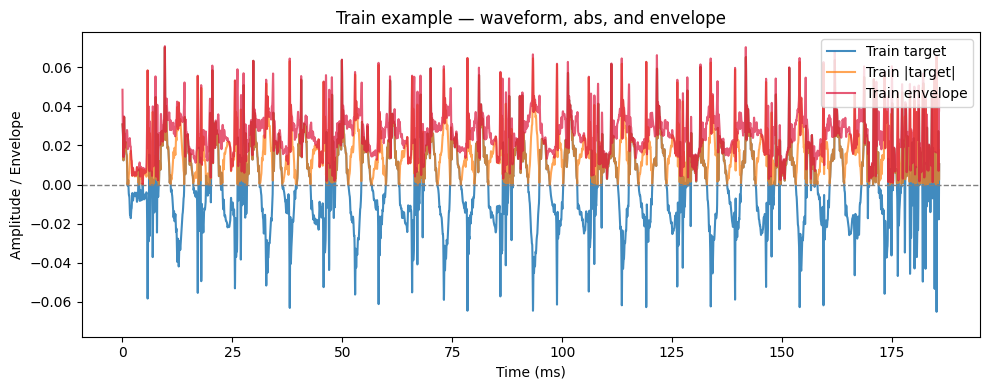

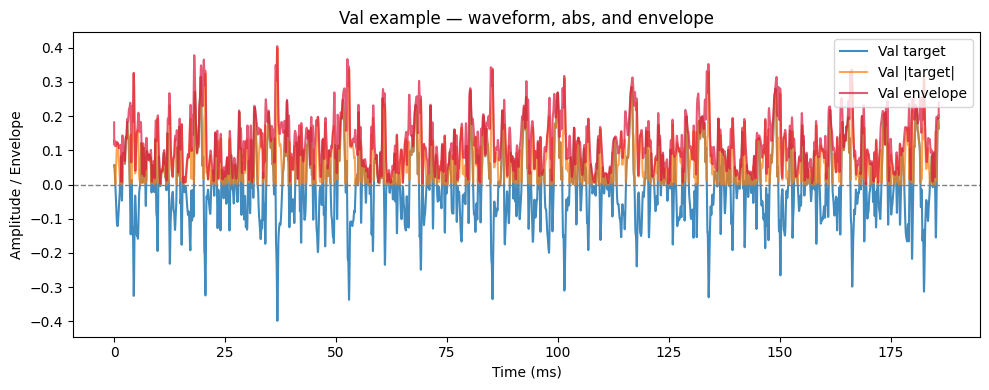

In [10]:
def plot_waveform_abs_and_envelope_from_loader(loader, subset_name: str, example_index: int = 0):
    """Draw one example waveform, its abs, and its envelope from a given DataLoader."""
    batch = next(iter(loader))
    input_audio, target_audio, params = batch  # shapes: (B, 1, T)

    # Use target (processed LA2A output) for envelope visualization
    x = target_audio[example_index, 0].detach().float()

    t = torch.arange(x.shape[-1], dtype=torch.float32) / SAMPLE_RATE * 1000.0  # ms

    with torch.no_grad():
        env = _envelope_analytic(x)
        # env_smooth = smooth_envelope(env, win_ms=10.0)
    x_abs = x.abs()

    # Common y-limits for all lines
    max_abs = float(torch.stack([x.abs().max(), env.abs().max()]).max())
    max_abs = max(max_abs, 1e-3)
    ylim = (-1.1 * max_abs, 1.1 * max_abs)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(t, x, label=f"{subset_name} target", alpha=0.85, color="C0")
    ax.plot(t, x_abs, label=f"{subset_name} |target|", alpha=0.7, color="tab:orange")
    ax.plot(t, env, label=f"{subset_name} envelope", alpha=0.7, color="crimson")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_ylabel("Amplitude / Envelope")
    ax.set_xlabel("Time (ms)")
    ax.set_title(f"{subset_name} example — waveform, abs, and envelope")
    ax.legend(loc="upper right")
    ax.set_ylim(*ylim)
    plt.tight_layout()
    plt.show()

# Visualize one example from train and one from val
plot_waveform_abs_and_envelope_from_loader(train_loader, "Train", example_index=0)
plot_waveform_abs_and_envelope_from_loader(val_loader, "Val", example_index=0)